In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Train XGBoost Regressor for claim frequency
xgb_regressor_freq = xgb.XGBRegressor(objective='reg:squarederror')
xgb_regressor_freq.fit(X, y_claim_frequency)

# Extract feature importance for XGBoost
xgb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_regressor_freq.feature_importances_
})

# Sort by importance
xgb_feature_importance = xgb_feature_importance.sort_values(by='Importance', ascending=False)

# Print feature importance
print("Feature Importance for XGBoost:")
print(xgb_feature_importance)


Feature Importance for XGBoost:
                       Feature  Importance
57          car_age_group_6-10    0.031645
21               Accel.11miles    0.030376
43              Car.use_Farmer    0.030188
26               Brake.09miles    0.026455
60     years_noclaims_group_6+    0.026290
..                         ...         ...
28               Brake.12miles    0.008419
53  annual_miles_group_15k-20k    0.007289
14             Pct.drive.wkend    0.006915
46             age_group_26-40    0.005697
56           car_age_group_15+    0.005614

[61 rows x 2 columns]


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Train LightGBM Regressor for claim frequency
lgb_regressor_freq = lgb.LGBMRegressor(objective='regression')
lgb_regressor_freq.fit(X, y_claim_frequency)

# Extract feature importance for LightGBM
lgb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_regressor_freq.feature_importances_
})

# Sort by importance
lgb_feature_importance = lgb_feature_importance.sort_values(by='Importance', ascending=False)

# Print feature importance
print("Feature Importance for LightGBM:")
print(lgb_feature_importance)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8633
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 61
[LightGBM] [Info] Start training from score 0.044940
Feature Importance for LightGBM:
                     Feature  Importance
2         Total.miles.driven         336
1          Annual.pct.driven         136
24             Brake.06miles         120
18             Accel.06miles         117
3              Pct.drive.mon         115
..                       ...         ...
48             age_group_61+           4
56         car_age_group_15+           2
59  years_noclaims_group_5-6           1
43            Car.use_Farmer           1
58  years_noclaims_group_3-4 

100%|██████████| 100/100 [00:51<00:00,  1.93it/s]

Shape of SHAP values: (1, 100, 61)
Shape of feature matrix: (100, 61)
Top 10 Feature Importance for FFNN using SHAP:
                Feature  Importance
2    annual_miles_group    0.015364
4  years_noclaims_group    0.013146
0             age_group    0.011852
5          Avgdays.week    0.010794
6        Pct.drive.2hrs    0.010567
7        Pct.drive.4hrs    0.009852
1    credit_score_group    0.009705
8        Pct.drive.3hrs    0.008739
3         car_age_group    0.008364
9      Insured.sex_Male    0.007965


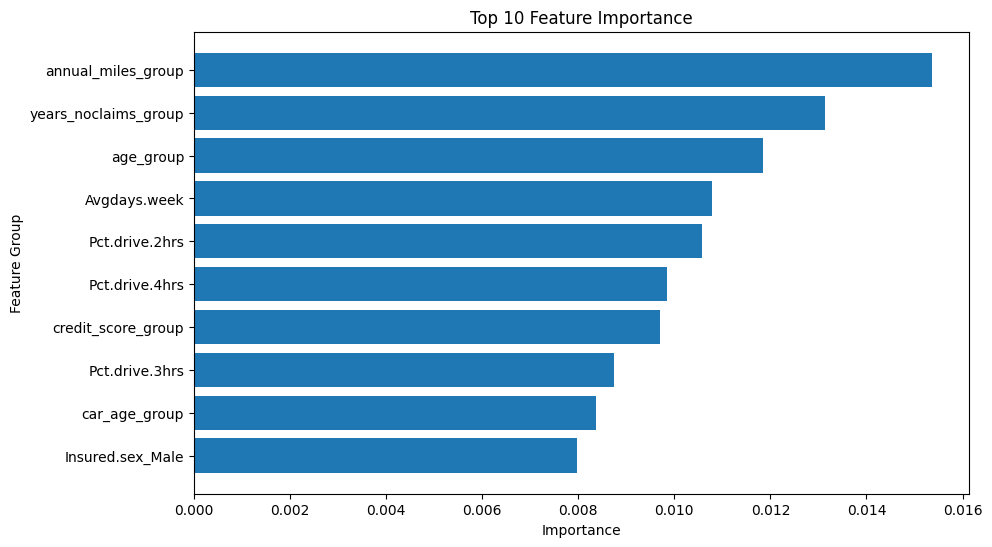

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity']).values
y_claim_frequency = df_final['NB_Claim'].values

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_claim_frequency, dtype=torch.float32).view(-1, 1)

# Define the FFNN model using PyTorch
class FFNN(nn.Module):
    def __init__(self, input_dim):
        super(FFNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize and train the model
input_dim = X.shape[1]
model = FFNN(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
model.train()
epochs = 10  # Reduced for demonstration purposes
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

# Define a prediction function for SHAP
def predict(X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy()

# Use SHAP KernelExplainer to explain the model's predictions
explainer = shap.KernelExplainer(predict, X[:100])  # Using a subset for the explainer
shap_values = explainer.shap_values(X[:100])

# Convert SHAP values to a NumPy array for summary plot
shap_values = np.array(shap_values)

# Ensure the shapes of SHAP values and feature matrix match
print(f"Shape of SHAP values: {shap_values.shape}")
print(f"Shape of feature matrix: {X[:100].shape}")

# Ensure shap_values is 2-dimensional for the summary plot
shap_values = shap_values[0] if len(shap_values) == 1 else shap_values

# Summarize SHAP values for feature importance
shap_values_summary = np.abs(shap_values).mean(axis=0)

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity']).columns,
    'Importance': shap_values_summary
}).sort_values(by='Importance', ascending=False)

# Define feature groups based on the given groupings
feature_groups = {
    'age_group': [
        'age_group_16-25', 'age_group_26-40', 'age_group_41-60', 'age_group_61+'
    ],
    'credit_score_group': [
        'credit_score_group_Poor', 'credit_score_group_Fair', 'credit_score_group_Good', 'credit_score_group_Excellent'
    ],
    'annual_miles_group': [
        'annual_miles_group_0-10k', 'annual_miles_group_10k-15k', 'annual_miles_group_15k-20k', 'annual_miles_group_20k+'
    ],
    'car_age_group': [
        'car_age_group_0-5', 'car_age_group_6-10', 'car_age_group_11-15', 'car_age_group_15+'
    ],
    'years_noclaims_group': [
        'years_noclaims_group_0-2', 'years_noclaims_group_3-4', 'years_noclaims_group_5-6', 'years_noclaims_group_6+'
    ]
}

# Aggregate SHAP values by feature groups
aggregated_feature_importance = {}

for group_name, features in feature_groups.items():
    aggregated_feature_importance[group_name] = feature_importance_df[feature_importance_df['Feature'].isin(features)]['Importance'].sum()

# Add non-grouped features to the aggregated importance
for feature in feature_importance_df['Feature']:
    if not any(feature in group for group in feature_groups.values()):
        aggregated_feature_importance[feature] = feature_importance_df[feature_importance_df['Feature'] == feature]['Importance'].values[0]

# Convert to DataFrame
aggregated_feature_importance_df = pd.DataFrame(list(aggregated_feature_importance.items()), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# Print top 10 feature importance
print("Top 10 Feature Importance for FFNN using SHAP:")
print(aggregated_feature_importance_df.head(10))

# Visualize the top 10 feature importance
plt.figure(figsize=(10, 6))
top_10_features = aggregated_feature_importance_df.head(10)
plt.barh(top_10_features['Feature'], top_10_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature Group')
plt.title('Top 10 Feature Importance')
plt.gca().invert_yaxis()
plt.show()
